In this notebook, we explore the implications of using `05_Combined_Data.csv` from a combination of `LaStBeRu_cosmo_ground`+`Chen et al. (2019)`+`Cao et al. (2015)` data:

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import rings2cosmo
import getdist
import numpy as np

from matplotlib import gridspec
from getdist import plots, MCSamples

pd.set_option('display.max_colwidth', None)

%matplotlib inline

In [2]:
mpl.rcParams.update(
    {
        "font.size": 20,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

# Global Variables:
dpi_global = 75
format_figure = ".pdf"
size_graphics = (10, 6.180)
font_legend = 14

In [3]:
# Load Data:
Combined_Data = pd.read_csv('05_Combined_Data.csv')
Combined_Data.head()

,JNAME,Original_ID,z_L,z_S,velDisp,velDispErr,velDisp0,velDisp0Err,theta_E,theta_ap,...,theta_E_rad,theta_ap_rad,theta_Eff_rad,Seeing_rad,Reference,in_cao_2015,in_cao_2017,in_chen_2019,in_liu_2022,in_lastberu_cosmo_ground
0,J002240.9+143110.1,J002240.9+143110.1,0.380506,2.7300,396.99310,55.420086,401.293768,57.340201,2.91,1.5,...,0.000014,0.000007,0.000012,0.000007,LaStBeRu_cosmo_ground,False,False,False,False,True
1,J002907.8-005550.5,J002907.8-005550.5,0.227043,0.9310,201.65935,18.190630,205.369169,19.612457,0.96,1.5,...,0.000005,0.000007,0.000011,0.000009,LaStBeRu_cosmo_ground,True,True,True,True,True
2,J002927.4+254401.8,J002927.4+254401.8,0.586881,2.4500,212.64645,51.071056,217.632298,52.735034,0.81,1.0,...,0.000004,0.000005,0.000007,0.000008,LaStBeRu_cosmo_ground,False,False,True,False,True
3,J004402.9+011312.6,J004402.9+011312.6,0.119582,0.1960,254.28107,12.229250,260.603600,15.114514,0.79,1.5,...,0.000004,0.000007,0.000010,0.000008,LaStBeRu_cosmo_ground,True,True,True,True,True
4,J014356.6-100633.7,J014356.6-100633.7,0.220969,1.1046,207.81186,18.661510,211.578823,20.121941,1.23,1.5,...,0.000006,0.000007,0.000011,0.000010,LaStBeRu_cosmo_ground,False,False,True,True,True


In [4]:
Combined_Data['for_plots'] = pd.NA
Combined_Data.loc[Combined_Data.query('in_cao_2015==False and in_chen_2019==False').index, 'for_plots'] = '$\mathrm{LaStBeRu\_cosmo\_ground}$'
Combined_Data.loc[Combined_Data.query('in_cao_2015==False and in_lastberu_cosmo_ground==False').index, 'for_plots'] = 'Chen et al. (2019)'
Combined_Data.loc[Combined_Data.query('in_chen_2019==False and in_lastberu_cosmo_ground==False').index, 'for_plots'] = 'Cao et al. (2015)'
Combined_Data.loc[Combined_Data.query('for_plots.isna()').index, 'for_plots'] = 'Intersection'

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/1050998976.py:2: SyntaxWarning: invalid escape sequence '\m'
  Combined_Data.loc[Combined_Data.query('in_cao_2015==False and in_chen_2019==False').index, 'for_plots'] = '$\mathrm{LaStBeRu\_cosmo\_ground}$'


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_649734/734570186.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').velDisp, \
/tmp/ipykernel_649734/734570186.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').velDisp, \
/tmp/ipykernel_649734/734570186.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel("$\sigma_v$ [km/s]")
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: Sy

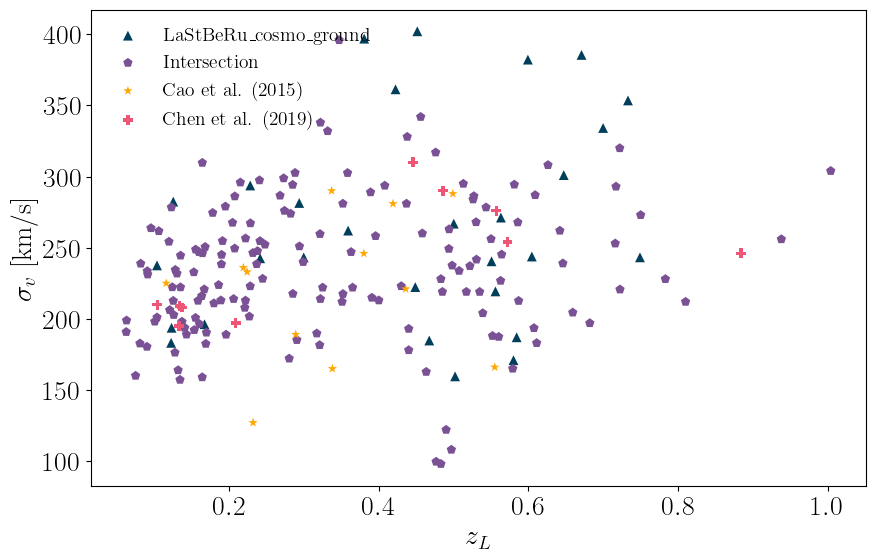

In [5]:
fig = plt.figure(figsize=size_graphics)
gs = gridspec.GridSpec(1, 1)

ax = plt.subplot(gs[0, 0 : 1 + 1])
ax.set_facecolor('none')
ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').velDisp, \
           marker='^', \
           s=50, \
           c='#003f5c',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"$\mathrm{LaStBeRu\_cosmo\_ground}$")
ax.scatter(Combined_Data.query('for_plots=="Intersection"').z_L, Combined_Data.query('for_plots=="Intersection"').velDisp, \
           marker='p', \
           s=50, \
           c='#7a5195',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"Intersection")
ax.scatter(Combined_Data.query('for_plots=="Cao et al. (2015)"').z_L, Combined_Data.query('for_plots=="Cao et al. (2015)"').velDisp, \
           marker='*', \
           s=50, \
           c= '#ffa600', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Cao et al. (2015)")
ax.scatter(Combined_Data.query('for_plots=="Chen et al. (2019)"').z_L, Combined_Data.query('for_plots=="Chen et al. (2019)"').velDisp, \
           marker='P', \
           s=50, \
           c= '#ef5675', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Chen et al. (2019)")

# ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='Black', lw=1, zorder=1, ls='--')
ax.legend(loc=2, fontsize=font_legend, frameon=False)

# Plotting options:
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel("$z_L$")
ax.set_ylabel("$\sigma_v$ [km/s]")
ax.set_axisbelow(False)

# plt.savefig(
#             "graphics/z_L_sigma_v"
#             + format_figure,
#             dpi=dpi_global,
#             bbox_inches="tight",
#         )

plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/2625713474.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_S, \
/tmp/ipykernel_649734/2625713474.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_S, \
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'


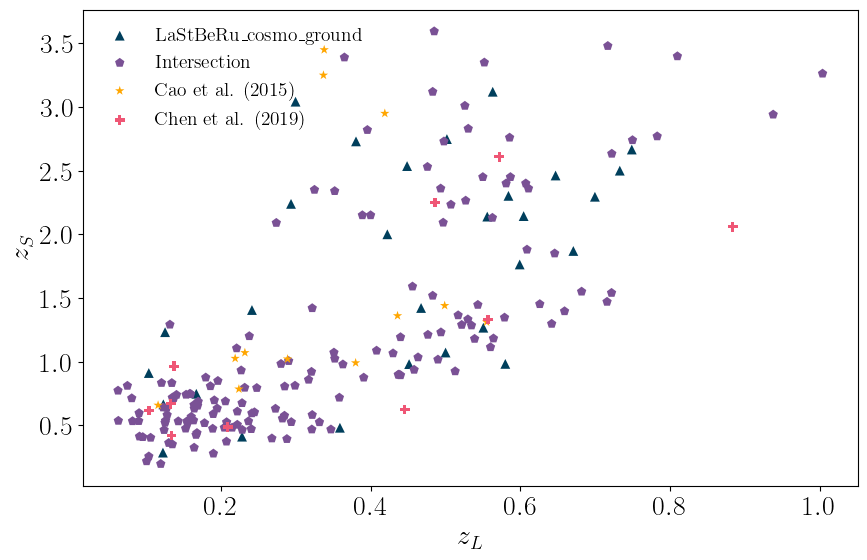

In [6]:
fig = plt.figure(figsize=size_graphics)
gs = gridspec.GridSpec(1, 1)

ax = plt.subplot(gs[0, 0 : 1 + 1])
ax.set_facecolor('none')
ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_S, \
           marker='^', \
           s=50, \
           c='#003f5c',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"$\mathrm{LaStBeRu\_cosmo\_ground}$")
ax.scatter(Combined_Data.query('for_plots=="Intersection"').z_L, Combined_Data.query('for_plots=="Intersection"').z_S, \
           marker='p', \
           s=50, \
           c='#7a5195',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"Intersection")
ax.scatter(Combined_Data.query('for_plots=="Cao et al. (2015)"').z_L, Combined_Data.query('for_plots=="Cao et al. (2015)"').z_S, \
           marker='*', \
           s=50, \
           c= '#ffa600', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Cao et al. (2015)")
ax.scatter(Combined_Data.query('for_plots=="Chen et al. (2019)"').z_L, Combined_Data.query('for_plots=="Chen et al. (2019)"').z_S, \
           marker='P', \
           s=50, \
           c= '#ef5675', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Chen et al. (2019)")

# ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='Black', lw=1, zorder=1, ls='--')
ax.legend(loc=2, fontsize=font_legend, frameon=False)

# Plotting options:
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel("$z_L$")
ax.set_ylabel("$z_S$")
ax.set_axisbelow(False)

# plt.savefig(
#            "graphics/z_L_z_S"
#             + format_figure,
#             dpi=dpi_global,
#             bbox_inches="tight",
#         )

plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/656500149.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').theta_E, \
/tmp/ipykernel_649734/656500149.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').theta_E, \
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'


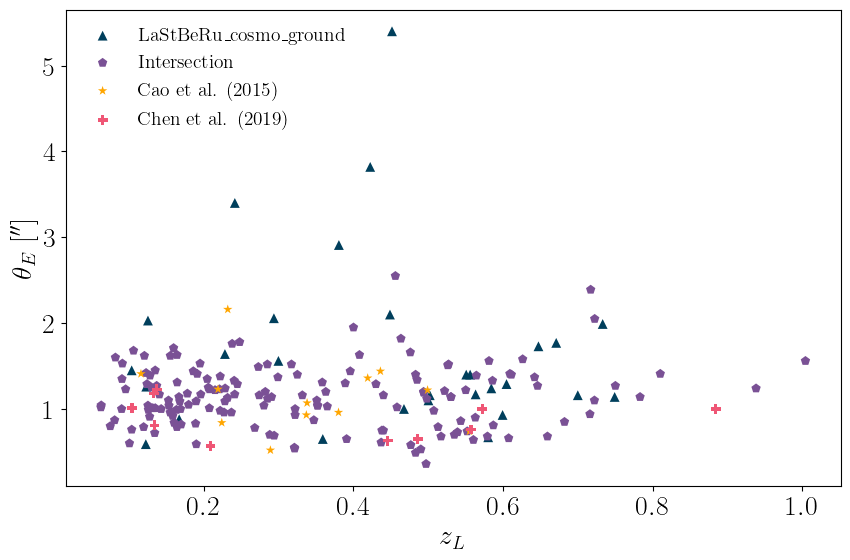

In [7]:
fig = plt.figure(figsize=size_graphics)
gs = gridspec.GridSpec(1, 1)

ax = plt.subplot(gs[0, 0 : 1 + 1])
ax.set_facecolor('none')
ax.scatter(Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').z_L, Combined_Data.query('for_plots=="$\mathrm{LaStBeRu\_cosmo\_ground}$"').theta_E, \
           marker='^', \
           s=50, \
           c='#003f5c',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"$\mathrm{LaStBeRu\_cosmo\_ground}$")
ax.scatter(Combined_Data.query('for_plots=="Intersection"').z_L, Combined_Data.query('for_plots=="Intersection"').theta_E, \
           marker='p', \
           s=50, \
           c='#7a5195',
           edgecolor='none', \
           linewidths=1, \
           zorder=4, \
           label=r"Intersection")
ax.scatter(Combined_Data.query('for_plots=="Cao et al. (2015)"').z_L, Combined_Data.query('for_plots=="Cao et al. (2015)"').theta_E, \
           marker='*', \
           s=50, \
           c= '#ffa600', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Cao et al. (2015)")
ax.scatter(Combined_Data.query('for_plots=="Chen et al. (2019)"').z_L, Combined_Data.query('for_plots=="Chen et al. (2019)"').theta_E, \
           marker='P', \
           s=50, \
           c= '#ef5675', \
           edgecolor='none', \
           linewidths=1, \
           zorder=5, \
           label=r"Chen et al. (2019)")

# ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='Black', lw=1, zorder=1, ls='--')
ax.legend(loc=2, fontsize=font_legend, frameon=False)

# Plotting options:
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel("$z_L$")
ax.set_ylabel(r"$\theta_E$ [$^{\prime\prime}$]")
ax.set_axisbelow(False)

# plt.savefig(
#             "graphics/z_L_theta_E"
#             + format_figure,
#             dpi=dpi_global,
#             bbox_inches="tight",
#         )

plt.show()

- Systems with $\theta_E$ > 2.8'':

In [8]:
Combined_Data.query('theta_E>2.8')

,JNAME,Original_ID,z_L,z_S,velDisp,velDispErr,velDisp0,velDisp0Err,theta_E,theta_ap,...,theta_ap_rad,theta_Eff_rad,Seeing_rad,Reference,in_cao_2015,in_cao_2017,in_chen_2019,in_liu_2022,in_lastberu_cosmo_ground,for_plots
0,J002240.9+143110.1,J002240.9+143110.1,0.380506,2.730,396.99310,55.420086,401.293768,57.340201,2.91,1.5,...,0.000007,0.000012,0.000007,LaStBeRu_cosmo_ground,False,False,False,False,True,$\mathrm{LaStBeRu\_cosmo\_ground}$
23,J084647.5+044605.0,J084647.5+044605.0,0.241446,1.405,242.57613,21.735540,240.255733,22.731528,3.40,1.5,...,0.000007,0.000017,0.000008,LaStBeRu_cosmo_ground,False,False,False,False,True,$\mathrm{LaStBeRu\_cosmo\_ground}$
69,J120602.1+514229.4,J120602.1+514229.4,0.422372,2.000,361.37347,51.795128,366.908660,53.800415,3.82,1.5,...,0.000007,0.000012,0.000011,LaStBeRu_cosmo_ground,False,False,False,False,True,$\mathrm{LaStBeRu\_cosmo\_ground}$
100,J151118.7+471340.2,J151118.7+471340.2,0.451489,0.980,402.16846,43.611140,401.853971,45.214166,5.40,1.5,...,0.000007,0.000015,0.000005,LaStBeRu_cosmo_ground,False,False,False,False,True,$\mathrm{LaStBeRu\_cosmo\_ground}$


- [J002240.9+143110.1](https://www.legacysurvey.org/viewer?ra=5.6704&dec=14.5195&layer=ls-dr9&zoom=16)
- [J084647.5+044605.0](https://www.legacysurvey.org/viewer?ra=131.6978&dec=4.7680&layer=ls-dr9&zoom=16)
- [J120602.1+514229.4](https://www.legacysurvey.org/viewer?ra=181.5085&dec=51.7082&layer=ls-dr9&zoom=16)
- [J151118.7+471340.2](https://www.legacysurvey.org/viewer?ra=227.8280&dec=47.2278&layer=ls-dr10&zoom=16)

# MCMC Experiments

Priors for each value:

- $\alpha$: Total mass density index
- $\beta$: Anisotropy parameter
- $\delta$: Luminosity density index
- $\gamma$: Parameterized Post-Newtonian parameter

In [9]:
alpha_true = 2
beta_true = 0.18
delta_true = 2.4
gamma_true = 1
labels = [r"\alpha", r"\beta", r"\delta", r"\gamma"]
nsteps = 15_000  # Number of steps

In [10]:
def get_mcmc(z_L, z_S, theta_E, theta_ap, seeing_atm, velDisp, velDispErr, label):
    sampler = rings2cosmo.logprobability_sampling(z_S, z_L, \
                                              velDisp, velDispErr, \
                                              theta_E, seeing_atm, theta_ap, \
                                              seed=42, alpha_ini=alpha_true, beta_ini=beta_true, delta_ini=delta_true, gamma_ini=gamma_true, \
                                              alpha_0_value=alpha_true, eps_alpha_0_value=0.08, beta_0_value=beta_true, eps_beta_0_value=0.13, delta_0_value=delta_true, eps_delta_0_value=0.11, \
                                              n_dim=4, n_walkers=64, n_burn=500, n_steps=nsteps, progress="notebook", processes=64)
    samples = MCSamples(samples=sampler.get_chain(discard=500, thin=1, flat=True), names=["alpha", "beta", "delta", "gamma"], labels=labels, \
                        label=label)
    # Customized triangle plot
    g = plots.get_subplot_plotter(subplot_size=4)
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.5
    g.settings.title_limit_fontsize = 20
    g.settings.axes_fontsize = 20
    g.settings.axes_labelsize = 20
    g.settings.legend_fontsize = 20
    g.triangle_plot(
        [samples],
        filled=True,
        legend_labels=[label],
        legend_loc="upper right",
        line_args=[{"ls": "--", "color": "black"}],
        contour_colors=["black"],
        title_limit=1,
        markers={
            "alpha": alpha_true, "beta": beta_true, "delta": delta_true, "gamma": gamma_true},
    )
    return samples

# 1. `LaStBeRu_cosmo_ground`+`Chen et al. (2019)`+`Cao et al. (2015)` data with $\sigma_v$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/2454525765.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


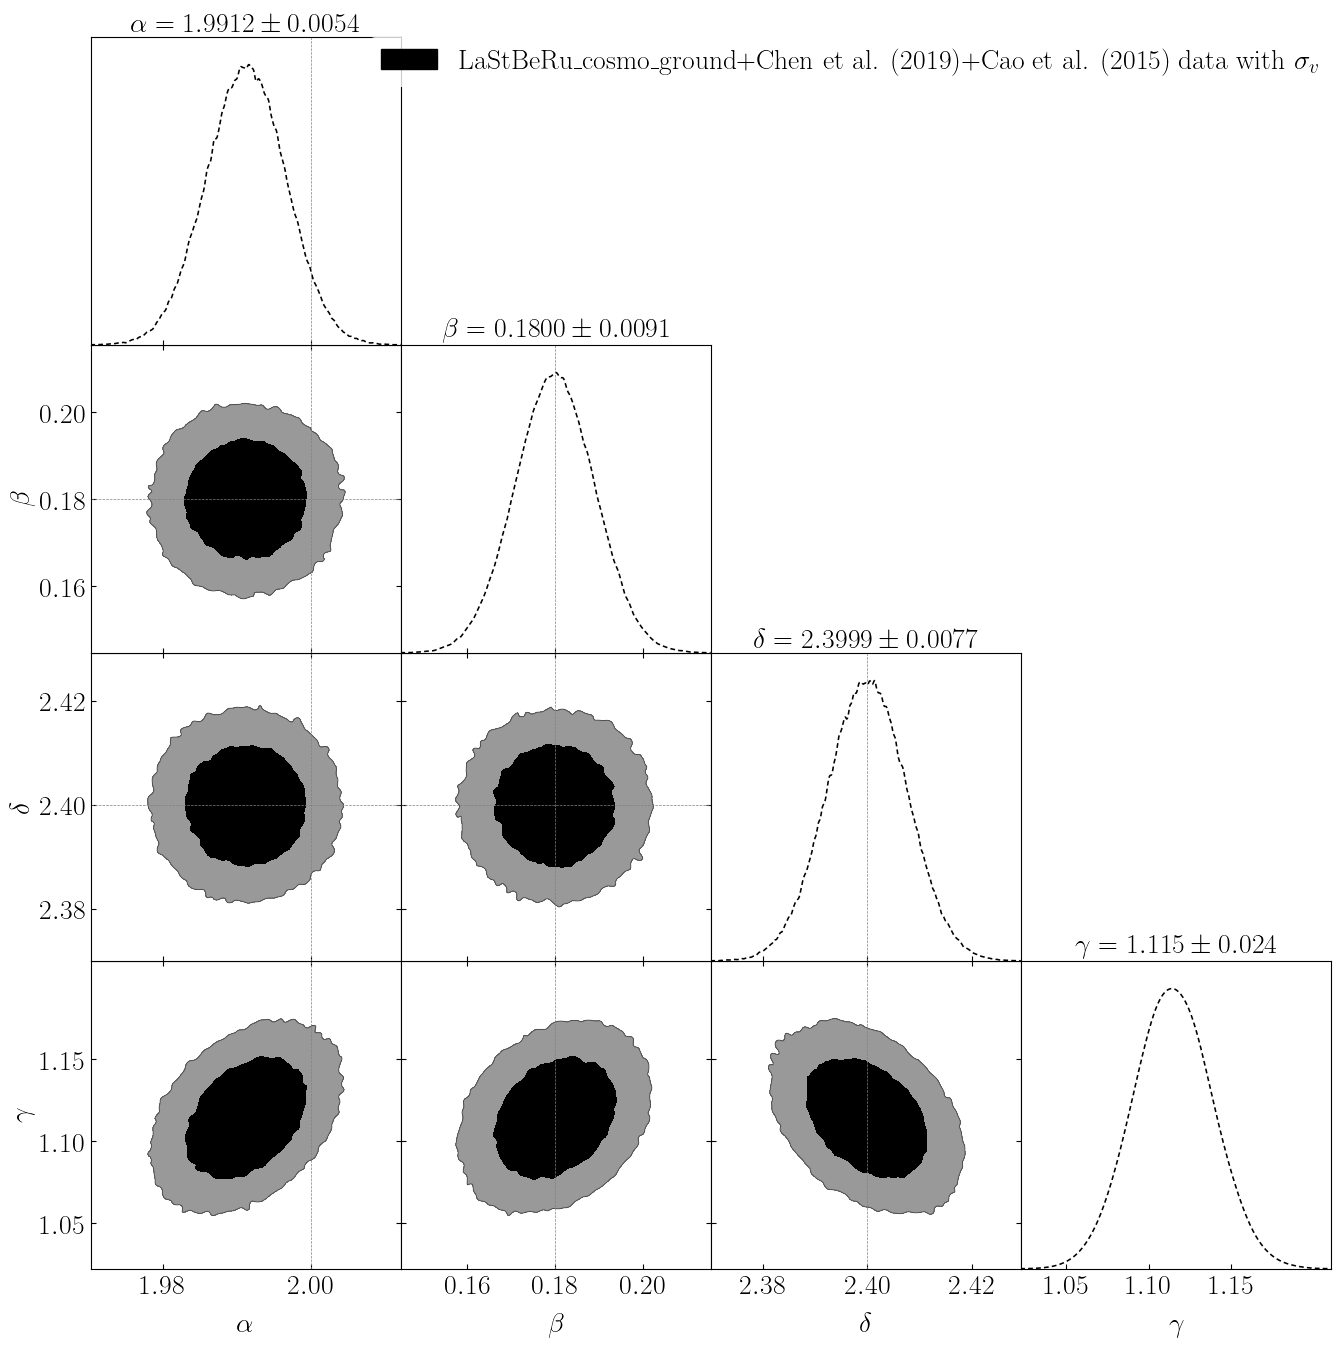

In [11]:
case_1 = get_mcmc(z_L=Combined_Data["z_L"].values, z_S=Combined_Data["z_S"].values, theta_E=Combined_Data["theta_E_rad"].values, theta_ap=Combined_Data["theta_ap_rad"].values, seeing_atm=Combined_Data["Seeing_rad"].values, \
                  velDisp=Combined_Data["velDisp"].values, velDispErr=Combined_Data["velDispErr"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$")

# 2. `LaStBeRu_cosmo_ground`+`Chen et al. (2019)`+`Cao et al. (2015)` data with $\sigma_0$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/849642119.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


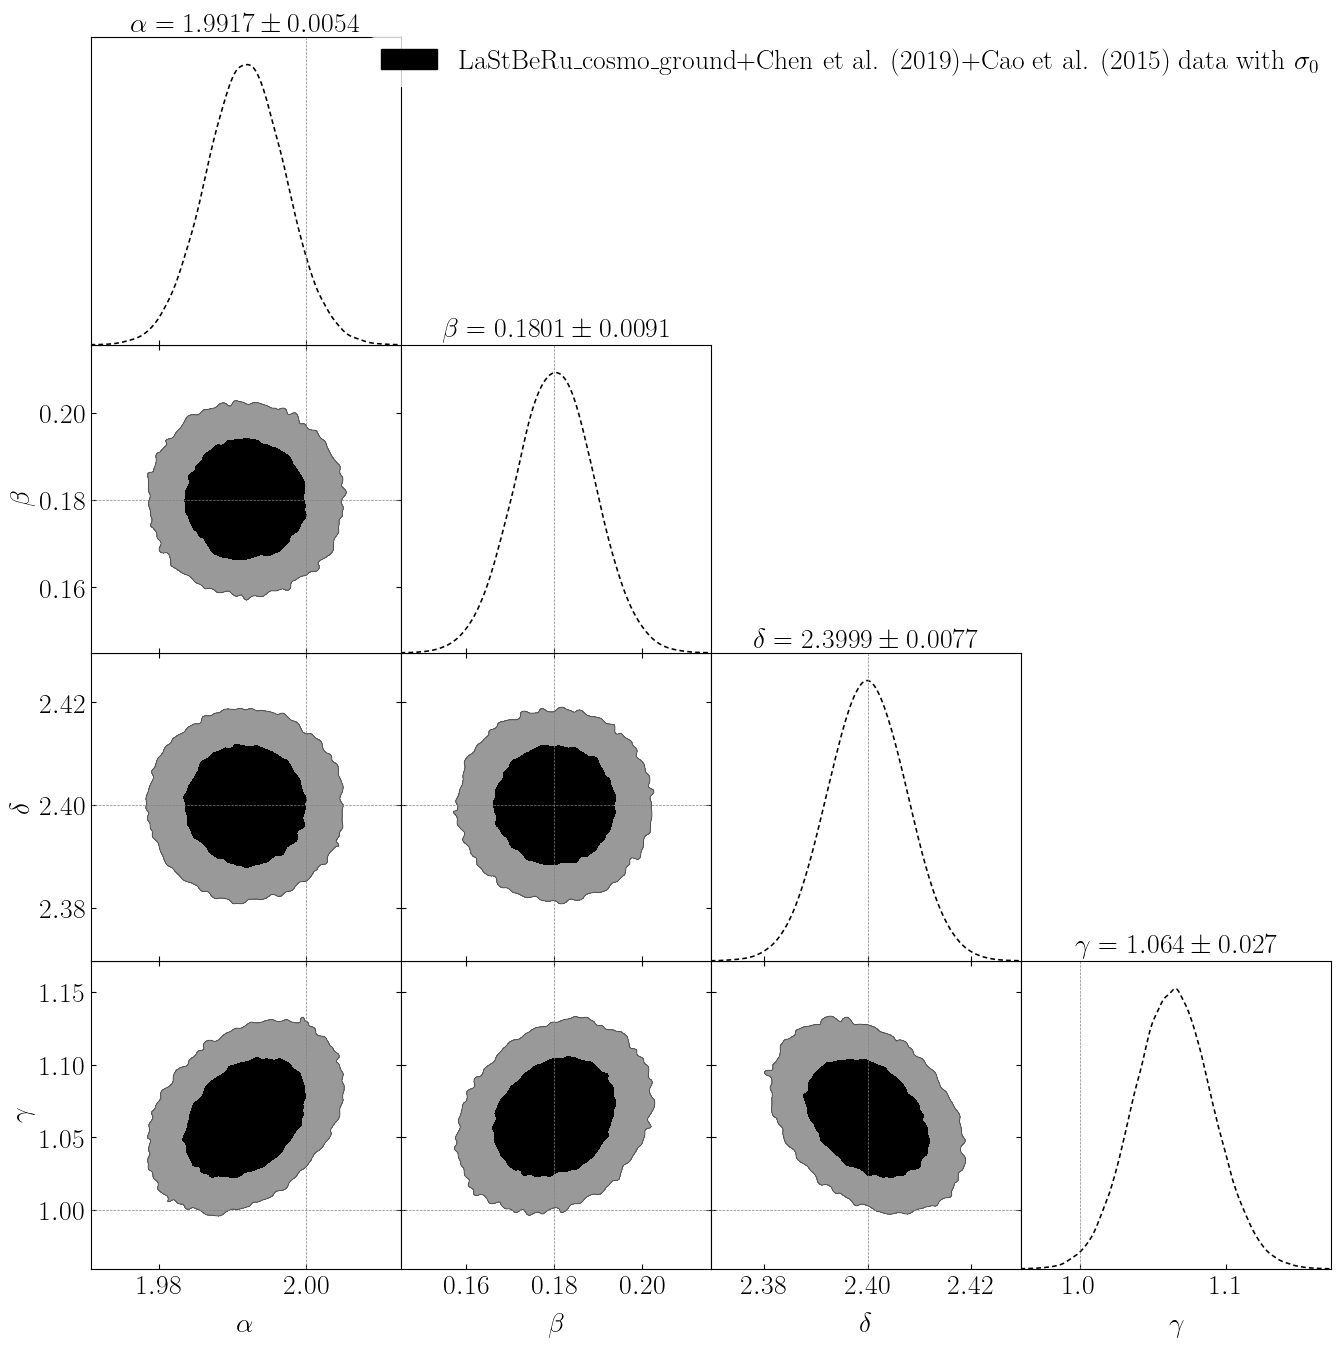

In [12]:
case_2 = get_mcmc(z_L=Combined_Data["z_L"].values, z_S=Combined_Data["z_S"].values, theta_E=Combined_Data["theta_E_rad"].values, theta_ap=Combined_Data["theta_ap_rad"].values, seeing_atm=Combined_Data["Seeing_rad"].values, \
                  velDisp=Combined_Data["velDisp0"].values, velDispErr=Combined_Data["velDisp0Err"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$")

# 3. Only `LaStBeRu_cosmo_ground` data (29 systems) $\sigma_v$

In [13]:
lastberu_cosmo_ground_only = Combined_Data.query('in_cao_2015==False and in_chen_2019==False').reset_index(drop=True)

In [14]:
len(lastberu_cosmo_ground_only)

29

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/1838516229.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_v$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


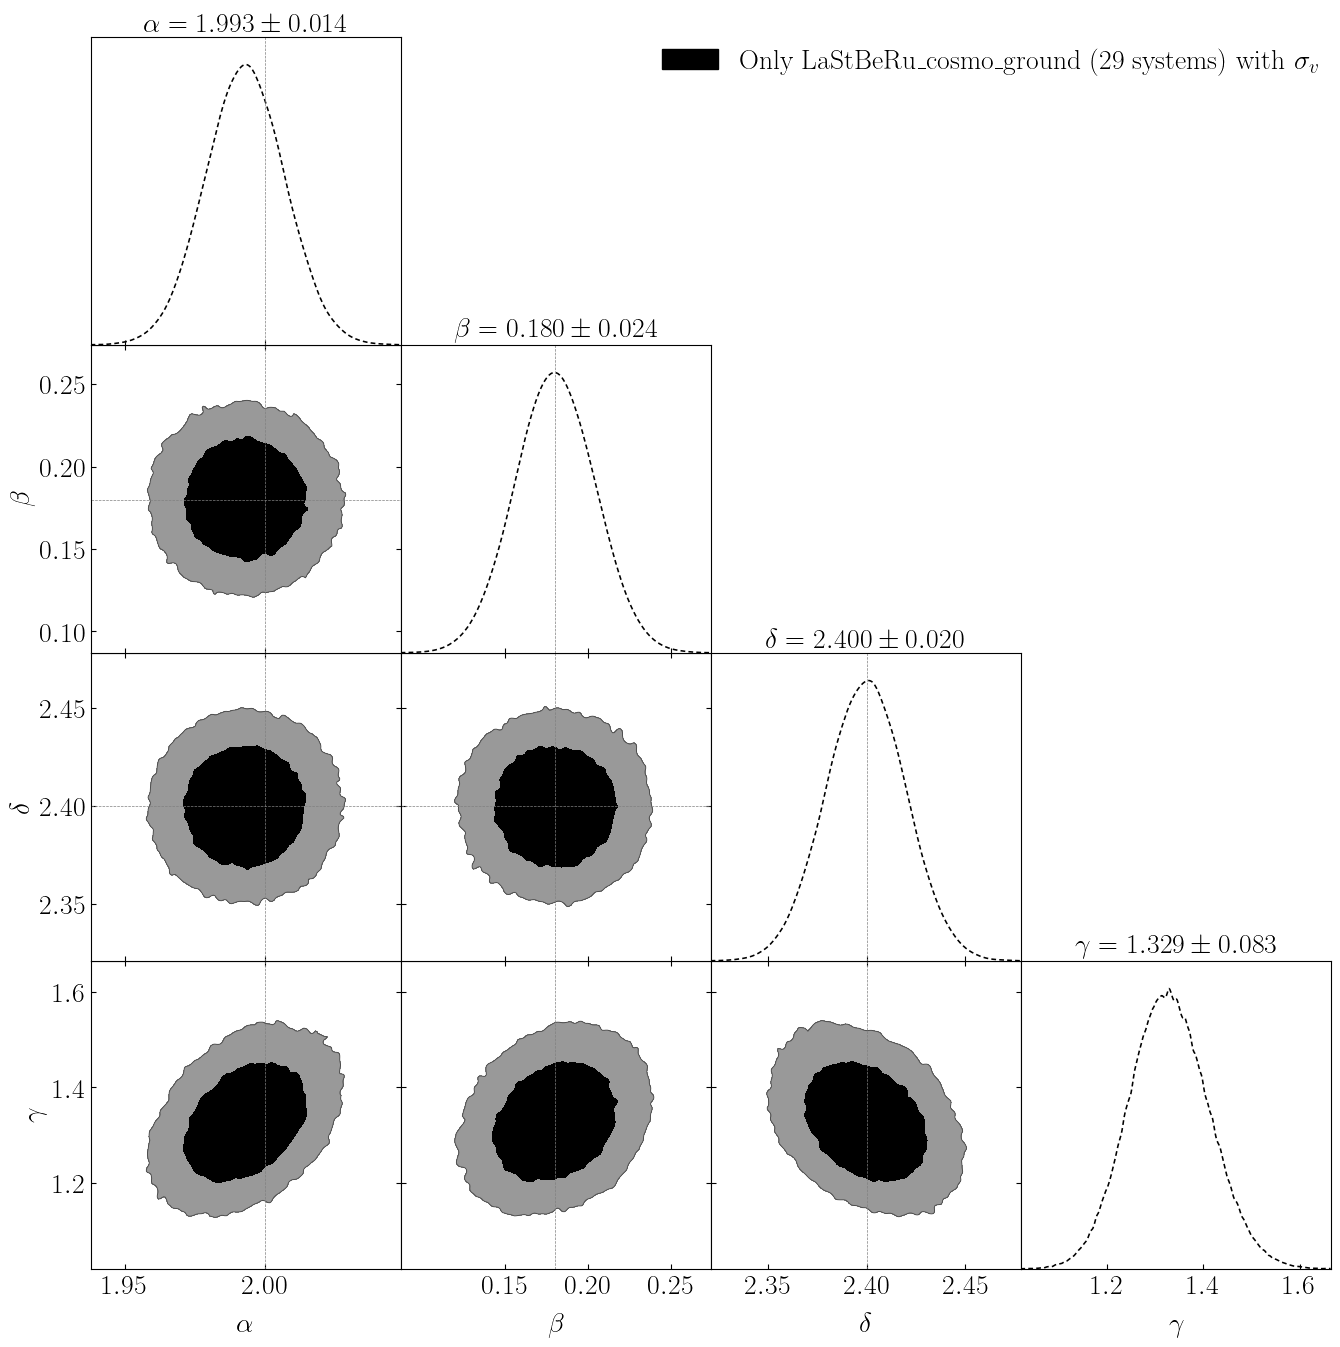

In [15]:
case_3 = get_mcmc(z_L=lastberu_cosmo_ground_only["z_L"].values, z_S=lastberu_cosmo_ground_only["z_S"].values, theta_E=lastberu_cosmo_ground_only["theta_E_rad"].values, theta_ap=lastberu_cosmo_ground_only["theta_ap_rad"].values, seeing_atm=lastberu_cosmo_ground_only["Seeing_rad"].values, \
                  velDisp=lastberu_cosmo_ground_only["velDisp"].values, velDispErr=lastberu_cosmo_ground_only["velDispErr"].values, \
                  label="Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_v$")

# 4. Only `LaStBeRu_cosmo_ground` data (29 systems) $\sigma_0$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/81396520.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_0$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


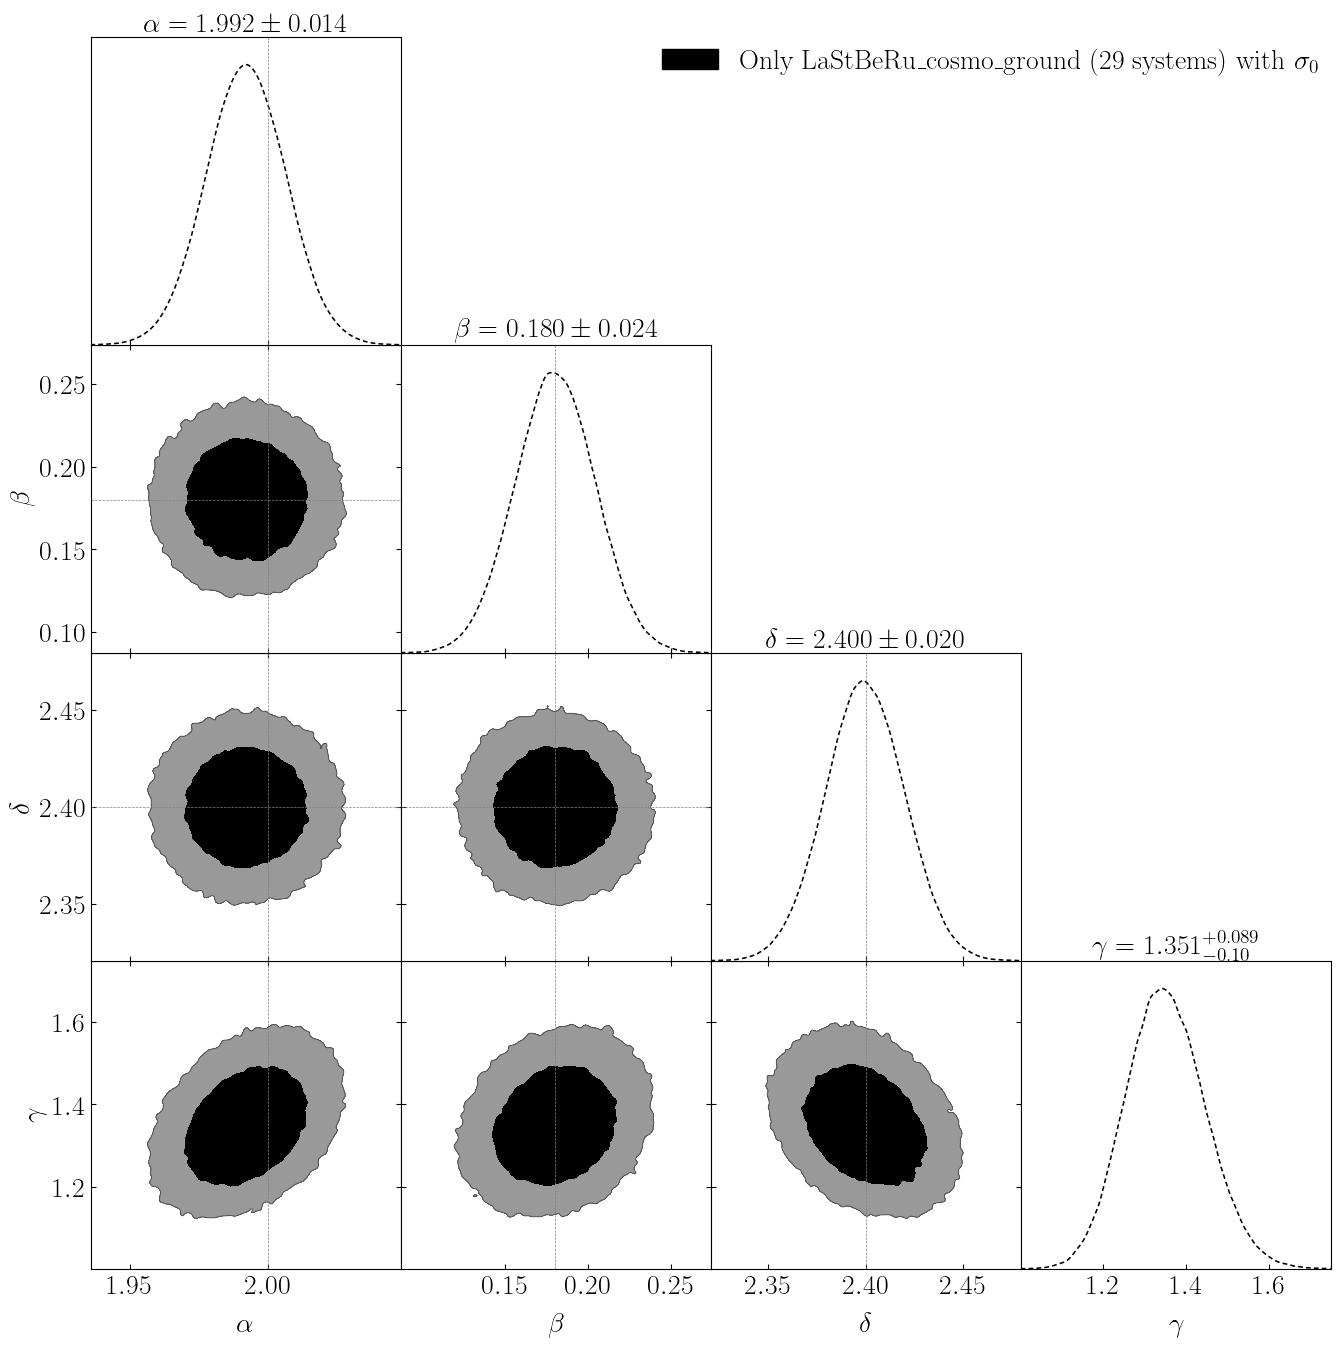

In [16]:
case_4 = get_mcmc(z_L=lastberu_cosmo_ground_only["z_L"].values, z_S=lastberu_cosmo_ground_only["z_S"].values, theta_E=lastberu_cosmo_ground_only["theta_E_rad"].values, theta_ap=lastberu_cosmo_ground_only["theta_ap_rad"].values, seeing_atm=lastberu_cosmo_ground_only["Seeing_rad"].values, \
                  velDisp=lastberu_cosmo_ground_only["velDisp0"].values, velDispErr=lastberu_cosmo_ground_only["velDisp0Err"].values, \
                  label="Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_0$")

# Results

In [17]:
full_stats = [np.hstack([case_1.getMeans(), np.sqrt(case_1.getVars())]).T,
              np.hstack([case_2.getMeans(), np.sqrt(case_2.getVars())]).T,
              np.hstack([case_3.getMeans(), np.sqrt(case_3.getVars())]).T,
              np.hstack([case_4.getMeans(), np.sqrt(case_4.getVars())]).T]
full_stats = np.vstack(full_stats)
columns = [r'$\alpha$', r'$\beta$', r'$\delta$', r'$\gamma$', r'$\mathrm{Std}(\alpha$)', r'$\mathrm{Std}(\beta$)', r'$\mathrm{Std}(\delta$)', r'$\mathrm{Std}(\gamma$)']
labels = [r'$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$', \
          r'Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_v$', \
          r'Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_0$']

df = pd.DataFrame(full_stats, columns=columns)
# df.insert(0, 'Case', labels)
df.index = labels
df.insert(8, 'Number of Systems', [len(Combined_Data), len(Combined_Data), len(lastberu_cosmo_ground_only), len(lastberu_cosmo_ground_only)])
df

,$\alpha$,$\beta$,$\delta$,$\gamma$,$\mathrm{Std}(\alpha$),$\mathrm{Std}(\beta$),$\mathrm{Std}(\delta$),$\mathrm{Std}(\gamma$),Number of Systems
$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$,1.991246,0.179972,2.399894,1.114604,0.005370,0.009082,0.007653,0.024192,206
$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$,1.991736,0.180103,2.399931,1.063908,0.005444,0.009082,0.007697,0.027202,206
Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_v$,1.993050,0.180101,2.399690,1.329178,0.014297,0.024097,0.020338,0.082774,29
Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_0$,1.992029,0.180315,2.399671,1.351435,0.014444,0.024193,0.020468,0.095705,29


In [16]:
full_stats = [np.hstack([case_1.getMeans(), np.sqrt(case_1.getVars())]).T,
              np.hstack([case_2.getMeans(), np.sqrt(case_2.getVars())]).T,
              np.hstack([case_3.getMeans(), np.sqrt(case_3.getVars())]).T,
              np.hstack([case_4.getMeans(), np.sqrt(case_4.getVars())]).T]
full_stats = np.vstack(full_stats)
columns = [r'$\alpha$', r'$\beta$', r'$\delta$', r'$\gamma$', r'$\mathrm{Std}(\alpha$)', r'$\mathrm{Std}(\beta$)', r'$\mathrm{Std}(\delta$)', r'$\mathrm{Std}(\gamma$)']
labels = [r'$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$', \
          r'Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_v$', \
          r'Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (29 systems) with $\sigma_0$']

df = pd.DataFrame(full_stats, columns=columns)
# df.insert(0, 'Case', labels)
df.index = labels
df.insert(8, 'Number of Systems', [len(Combined_Data), len(Combined_Data), len(lastberu_cosmo_ground_only), len(lastberu_cosmo_ground_only)])
df

,$\alpha$,$\beta$,$\delta$,$\gamma$,$\mathrm{Std}(\alpha$),$\mathrm{Std}(\beta$),$\mathrm{Std}(\delta$),$\mathrm{Std}(\gamma$),Number of Systems
$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_v$,1.993136,0.180005,2.399957,1.096951,0.004662,0.007736,0.006568,0.022190,280
$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015) data with $\sigma_0$,1.993333,0.180081,2.399994,1.034288,0.004686,0.007756,0.006561,0.025006,280
Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (103 systems) with $\sigma_v$,1.996270,0.180049,2.399824,1.108667,0.007746,0.012744,0.010886,0.050877,103
Only $\mathrm{LaStBeRu\_cosmo\_ground}$ (103 systems) with $\sigma_0$,1.995331,0.179829,2.399960,1.039699,0.007746,0.012859,0.010808,0.054829,103


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_649734/520040714.py:14: SyntaxWarning: invalid escape sequence '\m'
  g.add_legend(legend_labels=["$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015)", \
/tmp/ipykernel_649734/520040714.py:15: SyntaxWarning: invalid escape sequence '\m'
  "$\mathrm{LaStBeRu\_cosmo\_ground}$ only"], bbox_to_anchor=(0.55, 1.25), legend_loc='upper center', fontsize=14)


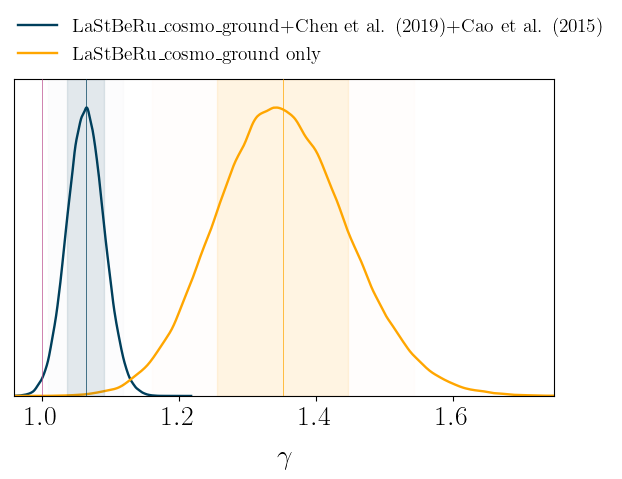

In [18]:
g = plots.get_single_plotter()
g.settings.title_limit_fontsize = 20
g.settings.axes_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.legend_fontsize = 20
g.settings.legend_frame = False
g.settings.figure_legend_frame = False
g.plot_1d([case_2, case_4], "gamma", line_args=[{"ls": "-", "color": "#003f5c"}, {"ls": "-", "color": "#ffa600"}])
g.add_x_bands(case_2.getMeans()[-1], np.sqrt(case_2.getVars()[-1]), alpha1=0.1, alpha2=0.01, color='#003f5c', zorder=2)
g.add_x_marker(case_2.getMeans()[-1], ls='-', color='#003f5c', zorder=5)
g.add_x_bands(case_4.getMeans()[-1], np.sqrt(case_4.getVars()[-1]), alpha1=0.1, alpha2=0.01, color='#ffa600', zorder=1)
g.add_x_marker(case_4.getMeans()[-1], ls='-', color='#ffa600', zorder=4)
g.add_x_marker(1, ls='-', color='#bc5090', zorder=3)
g.add_legend(legend_labels=["$\mathrm{LaStBeRu\_cosmo\_ground}$+Chen et al. (2019)+Cao et al. (2015)", \
                            "$\mathrm{LaStBeRu\_cosmo\_ground}$ only"], bbox_to_anchor=(0.55, 1.25), legend_loc='upper center', fontsize=14)

# plt.savefig(
#             "graphics/gamma_combined_lastberu"
#             + format_figure,
#             dpi=dpi_global,
#             bbox_inches="tight",
#         )

plt.show()